# Harbor Task Solution EDA

Exploratory analysis of `solution_grace/claude4.6_sonnet/harbor_tasks_8192/result.json`.

In [1]:
import json
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
RESULT_PATH = Path('../solution_grace/claude4.6_sonnet/harbor_tasks_8192/result.json')

with open(RESULT_PATH) as f:
    result = json.load(f)

print('started_at :', result['started_at'])
print('finished_at:', result['finished_at'])
print('n_total_trials:', result['n_total_trials'])

started_at : 2026-07-07T22:55:43.922089
finished_at: 2026-07-14T00:28:57.810205
n_total_trials: 26480


## Top-level stats

In [3]:
stats = result['stats']
eval_key = list(stats['evals'].keys())[0]
ev = stats['evals'][eval_key]

n_trials  = ev['n_trials']
n_errors  = ev['n_errors']
mean_reward = ev['metrics'][0]['mean']

print(f'Eval key  : {eval_key}')
print(f'n_trials  : {n_trials:,}')
print(f'n_errors  : {n_errors:,}  ({100*n_errors/n_trials:.1f}%)')
print(f'mean reward: {mean_reward:.4f}')

Eval key  : aicore-terminus-2__harbor_tasks_8192
n_trials  : 24,905
n_errors  : 1,853  (7.4%)
mean reward: 0.5652


## Reward distribution

In [4]:
reward_stats = ev['reward_stats']['reward']

# Build flat trial list: (task_id, attempt_id, reward)
rows = []
for reward_val, trial_ids in reward_stats.items():
    r = float(reward_val)
    for tid in trial_ids:
        # trial id format: task_XXXXXX_HASH__ATTEMPT
        parts = tid.rsplit('__', 1)
        task_id = parts[0]
        attempt = parts[1] if len(parts) == 2 else ''
        rows.append({'trial_id': tid, 'task_id': task_id, 'attempt': attempt, 'reward': r})

df = pd.DataFrame(rows)
print(f'Total scored trials : {len(df):,}')
print(f'Unique tasks        : {df["task_id"].nunique():,}')
print()
print(df['reward'].value_counts().sort_index())

Total scored trials : 24,905
Unique tasks        : 3,302

reward
0.0     9939
1.0    14966
Name: count, dtype: int64


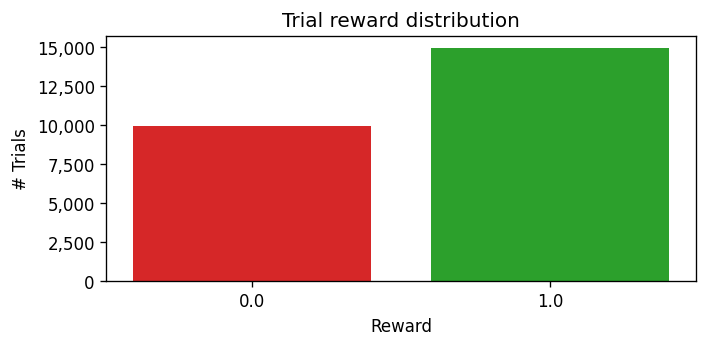

In [5]:
vc = df['reward'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([str(v) for v in vc.index], vc.values, color=['#d62728' if v < 0.5 else '#2ca02c' for v in vc.index])
ax.set_xlabel('Reward')
ax.set_ylabel('# Trials')
ax.set_title('Trial reward distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Per-task pass rate

Each task is attempted `n_attempts` times. We define **pass@k** as whether at least one attempt succeeded.

In [6]:
task_df = df.groupby('task_id').agg(
    n_attempts=('reward', 'count'),
    n_pass=('reward', lambda x: (x == 1.0).sum()),
    pass_rate=('reward', 'mean'),
).reset_index()

task_df['pass_any'] = task_df['n_pass'] > 0

print(f'Tasks with ≥1 pass : {task_df["pass_any"].sum():,} / {len(task_df):,}  '
      f'({100*task_df["pass_any"].mean():.1f}%)')
print(f'Tasks all-fail     : {(task_df["n_pass"] == 0).sum():,}')
print(f'Tasks all-pass     : {(task_df["n_pass"] == task_df["n_attempts"]).sum():,}')
print()
print('Attempt count distribution:')
print(task_df['n_attempts'].value_counts().sort_index())

Tasks with ≥1 pass : 2,092 / 3,302  (63.4%)
Tasks all-fail     : 1,210
Tasks all-pass     : 1,832

Attempt count distribution:
n_attempts
1       1
3       1
4       4
5      26
6     206
7     993
8    2071
Name: count, dtype: int64


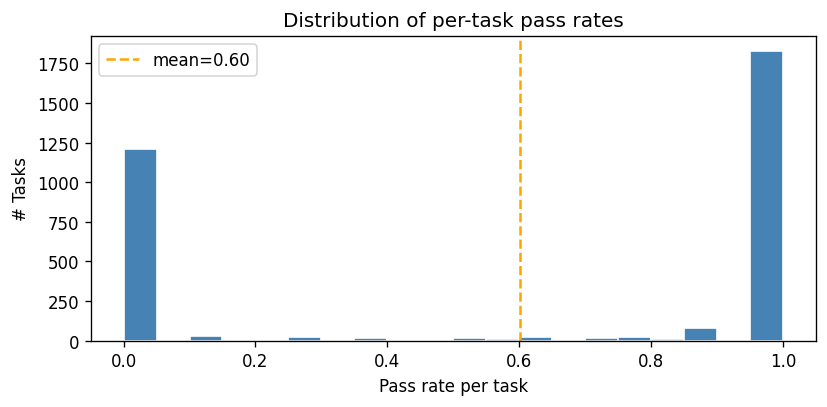

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(task_df['pass_rate'], bins=20, edgecolor='white', color='steelblue')
ax.axvline(task_df['pass_rate'].mean(), color='orange', linestyle='--', label=f'mean={task_df["pass_rate"].mean():.2f}')
ax.set_xlabel('Pass rate per task')
ax.set_ylabel('# Tasks')
ax.set_title('Distribution of per-task pass rates')
ax.legend()
plt.tight_layout()
plt.show()

## Error breakdown

                   exception  count
                RuntimeError   1539
           AgentTimeoutError    279
        VerifierTimeoutError     19
      AgentSetupTimeoutError      9
EnvironmentStartTimeoutError      7


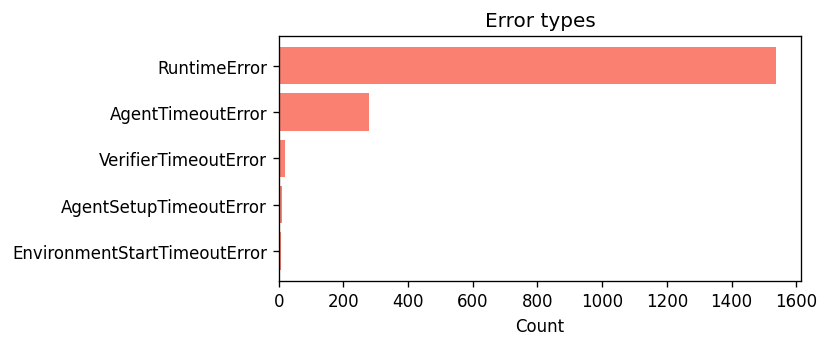

In [8]:
exc_stats = ev.get('exception_stats', {})

if exc_stats:
    exc_df = pd.DataFrame([
        {'exception': k, 'count': len(v) if isinstance(v, list) else v}
        for k, v in exc_stats.items()
    ]).sort_values('count', ascending=False)
    print(exc_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(exc_df['exception'], exc_df['count'], color='salmon')
    ax.set_xlabel('Count')
    ax.set_title('Error types')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('No exception_stats in result.json — checking reward_stats for error entries...')
    non_binary = {k: len(v) for k, v in reward_stats.items() if k not in ('0.0', '1.0')}
    if non_binary:
        print(non_binary)
    else:
        print(f'All {n_errors:,} errors are reflected in n_errors count; no per-type breakdown available.')

## Task index distribution

Task IDs encode a numeric index (`task_XXXXXX_...`). Checking whether coverage is uniform across the task corpus.

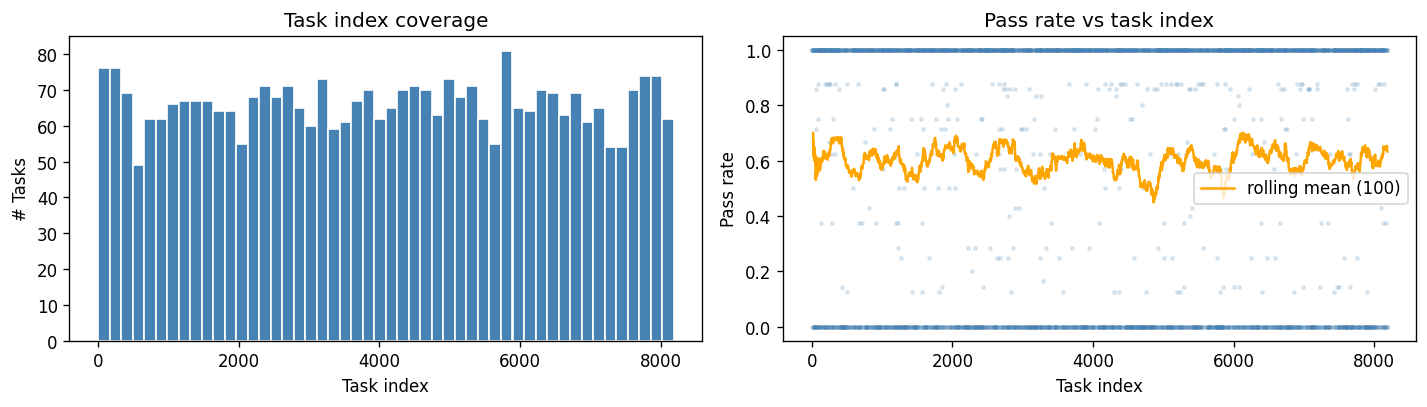

Task index range: 0 – 8186


In [9]:
task_df['task_num'] = task_df['task_id'].str.extract(r'task_(\d+)_').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(task_df['task_num'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Task index')
axes[0].set_ylabel('# Tasks')
axes[0].set_title('Task index coverage')

# Pass rate vs task index
axes[1].scatter(task_df['task_num'], task_df['pass_rate'], alpha=0.15, s=4, color='steelblue')
# Rolling mean
sorted_df = task_df.sort_values('task_num')
rolling = sorted_df.set_index('task_num')['pass_rate'].rolling(100, min_periods=10).mean()
axes[1].plot(rolling.index, rolling.values, color='orange', linewidth=1.5, label='rolling mean (100)')
axes[1].set_xlabel('Task index')
axes[1].set_ylabel('Pass rate')
axes[1].set_title('Pass rate vs task index')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Task index range: {task_df["task_num"].min()} – {task_df["task_num"].max()}')

## Hardest and easiest tasks

In [10]:
print('=== 10 hardest tasks (lowest pass rate, ≥4 attempts) ===')
display(task_df[task_df['n_attempts'] >= 4].nsmallest(10, 'pass_rate')[['task_id', 'n_attempts', 'n_pass', 'pass_rate']])

print()
print('=== 10 easiest tasks (highest pass rate, ≥4 attempts) ===')
display(task_df[task_df['n_attempts'] >= 4].nlargest(10, 'pass_rate')[['task_id', 'n_attempts', 'n_pass', 'pass_rate']])

=== 10 hardest tasks (lowest pass rate, ≥4 attempts) ===


,task_id,n_attempts,n_pass,pass_rate
4,task_000009_4ff5dcc5,8,0,0.0
6,task_000011_27873f74,8,0,0.0
9,task_000018_33ed2f80,8,0,0.0
10,task_000024_ed2dc7f2,8,0,0.0
12,task_000026_8709a3e8,5,0,0.0
14,task_000033_434ee06a,8,0,0.0
17,task_000041_482b4135,8,0,0.0
19,task_000043_62158261,8,0,0.0
21,task_000049_65fe5dda,6,0,0.0
23,task_000051_d71ba8b2,8,0,0.0



=== 10 easiest tasks (highest pass rate, ≥4 attempts) ===


,task_id,n_attempts,n_pass,pass_rate
0,task_000000_31a5cdae,8,8,1.0
1,task_000001_f70a6642,8,8,1.0
2,task_000002_9bcea96e,7,7,1.0
3,task_000008_ecccb4d4,8,8,1.0
5,task_000010_2e304580,8,8,1.0
7,task_000016_c4aa2f26,8,8,1.0
8,task_000017_4ac97938,8,8,1.0
11,task_000025_3ff6aa7b,8,8,1.0
13,task_000032_140e4c18,8,8,1.0
15,task_000034_2b21d02a,8,8,1.0


## pass@k curve

Fraction of tasks solved if we take the best of `k` attempts (subsampled from the 8 available).

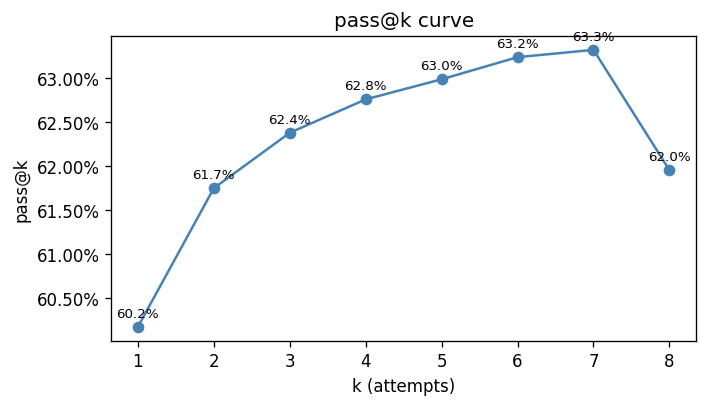

In [11]:
from math import comb

def pass_at_k(n, c, k):
    """Unbiased estimator of pass@k given n attempts, c passes."""
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

max_k = int(task_df['n_attempts'].max())
ks = list(range(1, max_k + 1))

passk_vals = []
for k in ks:
    eligible = task_df[task_df['n_attempts'] >= k]
    pk = eligible.apply(lambda r: pass_at_k(int(r['n_attempts']), int(r['n_pass']), k), axis=1).mean()
    passk_vals.append(pk)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks, passk_vals, marker='o', color='steelblue')
ax.set_xlabel('k (attempts)')
ax.set_ylabel('pass@k')
ax.set_title('pass@k curve')
ax.set_xticks(ks)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for k, v in zip(ks, passk_vals):
    ax.annotate(f'{v:.1%}', (k, v), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
plt.tight_layout()
plt.show()